# 04. Приоритизация гипотез и A/B-тест

Ноутбук 03 выявил узкие места. В настоящем ноутбуке они формулируются как гипотезы, гипотезы ранжируются, приоритетная проверяется экспериментом.

**Эксперимент является симуляцией.** Эффект в 20% прироста доходимости до каталога заложен в модель, поэтому раздел не доказывает гипотезу, а демонстрирует процедуру: расчёт необходимого размера выборки, рандомизацию, проверки корректности эксперимента, оценку метрик и границы применимости методов. Все базовые вероятности при этом рассчитаны по данным, а не назначены.

In [1]:
import sqlite3
from contextlib import closing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

DB_PATH = '../data/skillforge.db'
RANDOM_SEED = 42
sns.set_theme(style='whitegrid', rc={'font.family': 'DejaVu Sans'})

with closing(sqlite3.connect(DB_PATH)) as conn:
    df_users = pd.read_sql_query('SELECT * FROM mart_users', conn)

assert df_users['user_id'].is_unique, 'Дубликаты в mart_users'
print(f'Загружено пользователей: {len(df_users):,}')

Загружено пользователей: 25,000


## Реестр гипотез

Каждая гипотеза опирается на конкретный показатель из ноутбука 03. Без количественного основания формулировка представляет собой предположение, а не гипотезу.

Балльная оценка гипотез не применяется. Приоритет определяется тремя характеристиками, каждая из которых рассчитана по данным или получена статистической проверкой: размером затрагиваемого сегмента, величиной подтверждённого эффекта и объёмом доработки. При четырёх гипотезах, одна из которых опирается на эффект более чем на порядок сильнее остальных, присвоение баллов не добавляет информации к этим характеристикам и создаёт видимость расчёта там, где выбор определяется прямым сравнением.

In [2]:
hypotheses = [
    {
        'ID': 'H1',
        'Гипотеза': 'Ранний переход в каталог: CTA сразу после регистрации',
        'Сегмент': 'все новые регистрации',
        'Основание из данных': 'До каталога доходят 37.5%. У дошедших конверсия в оплату 9.95% против 1.38% у остальных, различие +8.57 п.п. при p < 0.001',
        'Решение': 'Заметная кнопка «Выбрать курс» на первом экране после регистрации',
        'Риски': 'Часть пользователей пропустит онбординг, если он несёт обучающую ценность',
    },
    {
        'ID': 'H2',
        'Гипотеза': 'Упрощение шага 2 онбординга на мобильных',
        'Сегмент': 'пользователи мобильных устройств',
        'Основание из данных': 'На шаге 2 отваливается 41.8%. На mobile онбординг завершают 28.5% против 37.6% на desktop, различие значимо при p = 0.015',
        'Решение': 'Сократить число полей, добавить автозаполнение и возможность пропустить шаг',
        'Риски': 'Уменьшение объёма собираемых данных о предпочтениях пользователя',
    },
    {
        'ID': 'H3',
        'Гипотеза': 'Догоняющая коммуникация после просмотра пейволла',
        'Сегмент': 'дошедшие до пейволла',
        'Основание из данных': 'Пейволл просмотрели 4 086 пользователей, оплату совершили 1 148. У 10% платящих между просмотром и оплатой проходит более 36 часов',
        'Решение': 'Напоминание на почту через сутки после просмотра тарифов',
        'Риски': 'Формирование ожидания скидки и снижение среднего чека',
    },
    {
        'ID': 'H4',
        'Гипотеза': 'Персонализация лендингов под каналы привлечения',
        'Сегмент': 'платный поиск',
        'Основание из данных': 'Различие конверсии между organic и paid_search составляет 0.2 п.п. и статистически незначимо (p = 0.545)',
        'Решение': 'Динамические посадочные страницы под ключевые слова',
        'Риски': 'Предмет оптимизации отсутствует: устойчивых различий между каналами в данных не выявлено',
    },
]

segment_size = {
    'H1': len(df_users),
    'H2': int((df_users['device_type'] == 'mobile').sum()),
    'H3': int(df_users['paywall_view_dt'].notna().sum()),
    'H4': int((df_users['traffic_channel'] == 'paid_search').sum()),
}

df_hypotheses = pd.DataFrame(hypotheses)
df_hypotheses['Пользователей'] = df_hypotheses['ID'].map(segment_size)
df_hypotheses['Доля аудитории, %'] = (df_hypotheses['Пользователей'] / len(df_users) * 100).round(1)

display(df_hypotheses[['ID', 'Гипотеза', 'Сегмент', 'Пользователей', 'Доля аудитории, %']])

with pd.option_context('display.max_colwidth', None):
    display(df_hypotheses[['ID', 'Основание из данных', 'Решение', 'Риски']])

,ID,Гипотеза,Сегмент,Пользователей,"Доля аудитории, %"
0,H1,Ранний переход в каталог: CTA сразу после реги...,все новые регистрации,25000,100.0
1,H2,Упрощение шага 2 онбординга на мобильных,пользователи мобильных устройств,13736,54.9
2,H3,Догоняющая коммуникация после просмотра пейволла,дошедшие до пейволла,4086,16.3
3,H4,Персонализация лендингов под каналы привлечения,платный поиск,7506,30.0


,ID,Основание из данных,Решение,Риски
0,H1,"До каталога доходят 37.5%. У дошедших конверсия в оплату 9.95% против 1.38% у остальных, различие +8.57 п.п. при p < 0.001",Заметная кнопка «Выбрать курс» на первом экране после регистрации,"Часть пользователей пропустит онбординг, если он несёт обучающую ценность"
1,H2,"На шаге 2 отваливается 41.8%. На mobile онбординг завершают 28.5% против 37.6% на desktop, различие значимо при p = 0.015","Сократить число полей, добавить автозаполнение и возможность пропустить шаг",Уменьшение объёма собираемых данных о предпочтениях пользователя
2,H3,"Пейволл просмотрели 4 086 пользователей, оплату совершили 1 148. У 10% платящих между просмотром и оплатой проходит более 36 часов",Напоминание на почту через сутки после просмотра тарифов,Формирование ожидания скидки и снижение среднего чека
3,H4,Различие конверсии между organic и paid_search составляет 0.2 п.п. и статистически незначимо (p = 0.545),Динамические посадочные страницы под ключевые слова,Предмет оптимизации отсутствует: устойчивых различий между каналами в данных не выявлено


Экспериментом проверяется гипотеза H1. Основания:

- **охват** — единственная гипотеза, затрагивающая всю новую аудиторию. Остальные ограничены сегментами от 16.3% до 54.9% пользователей;
- **величина эффекта** — опирается на наибольшее из подтверждённых различий: +8.57 п.п. конверсии при p < 0.001. Следующее по величине подтверждённое различие, между устройствами, составляет +0.68 п.п., то есть в двенадцать раз меньше;
- **объём доработки** — требуется размещение одного элемента интерфейса, тогда как H2 предполагает переработку мобильного сценария.

Гипотеза H4 отклонена по результатам анализа: различие конверсии между каналами статистически незначимо (p = 0.545), то есть предмет оптимизации отсутствует. Гипотеза сохранена в реестре для фиксации основания отказа.

## Дизайн: необходимый объём наблюдений

In [3]:
ALPHA = 0.05
POWER = 0.80

baseline_cr = df_users['first_payment_dt'].notna().mean()
z_alpha = stats.norm.ppf(1 - ALPHA / 2)
z_power = stats.norm.ppf(POWER)


def required_sample_size(baseline, relative_mde):
    target = baseline * (1 + relative_mde)
    numerator = (z_alpha * np.sqrt(2 * baseline * (1 - baseline))
                 + z_power * np.sqrt(baseline * (1 - baseline) + target * (1 - target))) ** 2
    return int(np.ceil(numerator / (target - baseline) ** 2)), target


sample_size_scenarios = pd.DataFrame([
    {
        'Относительный MDE': f'+{int(mde * 100)}%',
        'Целевой CR': f'{target * 100:.2f}%',
        'Прирост (п.п.)': f'+{(target - baseline_cr) * 100:.2f}',
        'На группу': f'{size:,}',
        'Всего': f'{size * 2:,}',
    }
    for mde in [0.10, 0.15, 0.20, 0.25]
    for size, target in [required_sample_size(baseline_cr, mde)]
])

print(f'Базовый CR: {baseline_cr * 100:.2f}% | alpha = {ALPHA}, power = {POWER}')
display(sample_size_scenarios)

Базовый CR: 4.59% | alpha = 0.05, power = 0.8


,Относительный MDE,Целевой CR,Прирост (п.п.),На группу,Всего
0,+10%,5.05%,+0.46,"33,076","66,152"
1,+15%,5.28%,+0.69,"14,801","29,602"
2,+20%,5.51%,+0.92,"8,381","16,762"
3,+25%,5.74%,+1.15,"5,400","10,800"


### Чувствительность теста

При базовой конверсии 4.59% для надёжного обнаружения относительного прироста в 20% требуется 8 381 пользователь на группу, для 15% — 14 801, для 10% — 33 076.

Полугодовой трафик в 25 000 регистраций при разделении 50/50 обеспечивает около 12 500 наблюдений на группу. Следовательно, тест уверенно обнаруживает эффекты от 15–20% и выше, тогда как меньшие эффекты остаются за пределами его чувствительности. Данное значение следует учитывать при интерпретации результатов.

## Ковариаты и контроль дисперсии

In [4]:
PRE_EXPERIMENT_FEATURES = ['traffic_channel', 'device_type', 'country']

df_pre = df_users[['user_id'] + PRE_EXPERIMENT_FEATURES + ['total_revenue']].copy()
df_pre['segment_arpu'] = df_pre.groupby(PRE_EXPERIMENT_FEATURES)['total_revenue'].transform('mean')

correlations = (
    pd.get_dummies(df_pre[PRE_EXPERIMENT_FEATURES], drop_first=True, dtype=int)
    .assign(segment_arpu=df_pre['segment_arpu'], revenue=df_pre['total_revenue'])
    .corr()['revenue']
    .drop('revenue')
    .sort_values(ascending=False)
    .to_frame(name='корреляция_с_выручкой')
    .round(4)
)

display(correlations)

,корреляция_с_выручкой
segment_arpu,0.0614
country_UZ,0.0225
traffic_channel_paid_search,0.0125
device_type_mobile,0.0032
country_Other,0.0023
traffic_channel_targeted_ads,-0.0002
country_KZ,-0.0026
device_type_tablet,-0.0061
country_RU,-0.0080
traffic_channel_organic,-0.0081


### Оценка применимости CUPED

Единственными признаками, известными до начала эксперимента, являются канал привлечения, устройство и страна. Наилучший производный признак — средний ARPU сегмента — коррелирует с выручкой на уровне 0.06. Теоретический предел сокращения дисперсии для метода CUPED равен квадрату корреляции, то есть 0.4%.

Причина носит методологический, а не технический характер. CUPED снижает дисперсию за счёт вычитания доэкспериментального поведения того же пользователя: выручки предыдущего месяца, активности предыдущей недели. В эксперименте на вновь зарегистрированных пользователях доэкспериментальный период отсутствует по определению.

Вследствие этого контроль дисперсии в данном дизайне обеспечивается стратификацией при рандомизации. Расчёт CUPED тем не менее приводится ниже: количественная оценка предпочтительнее ссылки на неприменимость метода.

## Симуляция эксперимента

In [5]:
CATALOG_UPLIFT = 1.20

catalog_rate = df_users['catalog_view_dt'].notna().mean()
has_catalog = df_users['catalog_view_dt'].notna()
pay_rate_with_catalog = df_users.loc[has_catalog, 'first_payment_dt'].notna().mean()
pay_rate_without_catalog = df_users.loc[~has_catalog, 'first_payment_dt'].notna().mean()

print(f'Из данных: доходимость до каталога {catalog_rate:.4f}, '
      f'CR с каталогом {pay_rate_with_catalog:.4f}, без каталога {pay_rate_without_catalog:.4f}')

rng = np.random.default_rng(RANDOM_SEED)

ab_test = df_users[['user_id'] + PRE_EXPERIMENT_FEATURES].copy()
ab_test['strata'] = ab_test[PRE_EXPERIMENT_FEATURES].agg('_'.join, axis=1)

ab_test = ab_test.sample(frac=1, random_state=RANDOM_SEED)
ab_test['variant'] = np.where(ab_test.groupby('strata').cumcount() % 2 == 0, 'A', 'B')
ab_test = ab_test.sort_index()

catalog_probability = np.where(ab_test['variant'] == 'B', catalog_rate * CATALOG_UPLIFT, catalog_rate)
ab_test['viewed_catalog'] = rng.random(len(ab_test)) < catalog_probability

payment_probability = np.where(ab_test['viewed_catalog'], pay_rate_with_catalog, pay_rate_without_catalog)
ab_test['primary_metric'] = (rng.random(len(ab_test)) < payment_probability).astype(int)

paying_revenue = df_users.loc[df_users['total_revenue'] > 0, 'total_revenue'].to_numpy()
ab_test['revenue'] = np.where(
    ab_test['primary_metric'] == 1, rng.choice(paying_revenue, size=len(ab_test)), 0.0)

ab_test['pre_experiment_covariate'] = ab_test['strata'].map(
    df_users.assign(strata=ab_test['strata']).groupby('strata')['total_revenue'].mean())

display(ab_test['variant'].value_counts().to_frame(name='users_count'))
ab_test.head()

Из данных: доходимость до каталога 0.3748, CR с каталогом 0.0995, без каталога 0.0138


,users_count
variant,
A,12511
B,12489


,user_id,traffic_channel,device_type,country,strata,variant,viewed_catalog,primary_metric,revenue,pre_experiment_covariate
0,10001,paid_search,desktop,RU,paid_search_desktop_RU,B,False,0,0.0,383.846345
1,10002,targeted_ads,mobile,KZ,targeted_ads_mobile_KZ,A,False,0,0.0,369.050000
2,10003,organic,desktop,RU,organic_desktop_RU,B,False,0,0.0,352.000255
3,10004,paid_search,desktop,BY,paid_search_desktop_BY,B,False,0,0.0,362.009804
4,10005,influencers,desktop,RU,influencers_desktop_RU,A,True,0,0.0,334.419277


Применяется стратифицированная рандомизация: внутри каждой связки «канал + устройство + страна» пользователи перемешиваются и распределяются по группам поочерёдно. Это обеспечивает баланс сегментов без дополнительных проверок и снижает дисперсию оценки.

Базовые вероятности рассчитаны по данным: доходимость до каталога 0.3748, конверсия в оплату при просмотре каталога 0.0995, без просмотра — 0.0138. Гипотеза добавляет группе B 20% к доходимости до каталога и не изменяет прочих параметров; эффект на оплату возникает только как следствие. Выручка платящих пользователей формируется выборкой из эмпирического распределения фактически платящих, вследствие чего B2B-хвост, выявленный в ноутбуке 03, сохраняется.

## Проверка корректности эксперимента

In [6]:
variant_counts = ab_test['variant'].value_counts()
srm_stat, srm_p_value = stats.chisquare(f_obs=variant_counts)

print(f'SRM: p-value = {srm_p_value:.4f} | '
      f"{'сплит сломан' if srm_p_value < 0.01 else 'сплит корректен'}")

display(pd.DataFrame({
    'Группа': variant_counts.index,
    'Пользователей': variant_counts.values,
    'Доля (%)': (variant_counts.values / variant_counts.sum() * 100).round(2),
}))

for feature in PRE_EXPERIMENT_FEATURES:
    display(pd.crosstab(ab_test[feature], ab_test['variant'], normalize='index').mul(100).round(2))

SRM: p-value = 0.8893 | сплит корректен


,Группа,Пользователей,Доля (%)
0,A,12511,50.04
1,B,12489,49.96


variant,A,B
traffic_channel,,
influencers,50.10,49.90
organic,50.02,49.98
paid_search,50.05,49.95
targeted_ads,50.02,49.98


variant,A,B
device_type,,
desktop,50.04,49.96
mobile,50.02,49.98
tablet,50.23,49.77


variant,A,B
country,,
BY,50.14,49.86
KZ,50.05,49.95
Other,50.22,49.78
RU,50.01,49.99
UZ,50.20,49.80


Разделение корректно: 12 511 против 12 489 наблюдений, SRM-тест даёт p = 0.89 при пороге 0.01. Баланс по устройствам, каналам и странам сохраняется в пределах 50 ± 0.25 п.п., что подтверждает работоспособность стратификации.

## Распределение выручки

In [7]:
revenue_all = ab_test.groupby('variant')['revenue'].agg(
    users='count', arpu='mean', median='median', std='std',
    skew=lambda s: s.skew(), zero_share_pct=lambda s: (s == 0).mean() * 100, max_value='max',
).round(2)

revenue_paying = ab_test[ab_test['revenue'] > 0].groupby('variant')['revenue'].agg(
    paying_users='count', arppu='mean', median='median', std='std',
    skew=lambda s: s.skew(), p90=lambda s: s.quantile(0.90), max_value='max',
).round(2)

display(revenue_all, revenue_paying)

,users,arpu,median,std,skew,zero_share_pct,max_value
variant,,,,,,,
A,12511,377.20,0.0,7042.22,90.82,95.4,732815.62
B,12489,508.16,0.0,9753.73,68.27,94.8,732815.62


,paying_users,arppu,median,std,skew,p90,max_value
variant,,,,,,,
A,575,8207.31,2490.0,31882.16,20.65,15890.0,732815.62
B,650,9763.80,3480.0,41714.20,16.16,14900.0,732815.62


### Свойства распределения выручки

95% значений равны нулю, асимметрия составляет 68 и 91 по группам, максимальное значение — 732 816 ₽ при среднем около 400 ₽. Стандартное отклонение превышает среднее в двадцать раз.

Для метрики с такими свойствами обычный t-тест по средним ненадёжен: одно-два крупных значения смещают среднее сильнее, чем весь остальной массив наблюдений. Далее метрика проверяется бутстрапом.

## Результаты по конверсиям

In [8]:
def evaluate_proportion(metric_name, column):
    """Z-тест разницы долей с доверительным интервалом Уилсона для каждой группы."""
    control = ab_test.loc[ab_test['variant'] == 'A', column].astype(int)
    treatment = ab_test.loc[ab_test['variant'] == 'B', column].astype(int)

    n_control, n_treatment = len(control), len(treatment)
    p_control, p_treatment = control.mean(), treatment.mean()

    pooled = (control.sum() + treatment.sum()) / (n_control + n_treatment)
    pooled_se = np.sqrt(pooled * (1 - pooled) * (1 / n_control + 1 / n_treatment))
    z_stat = (p_treatment - p_control) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    diff_se = np.sqrt(p_control * (1 - p_control) / n_control + p_treatment * (1 - p_treatment) / n_treatment)
    margin = stats.norm.ppf(1 - ALPHA / 2) * diff_se

    return {
        'Метрика': metric_name,
        'Контроль (A)': f'{p_control * 100:.2f}% ({control.sum():,}/{n_control:,})',
        'Тест (B)': f'{p_treatment * 100:.2f}% ({treatment.sum():,}/{n_treatment:,})',
        'Прирост (п.п.)': f'{(p_treatment - p_control) * 100:+.2f}',
        'Относительный прирост': f'{(p_treatment / p_control - 1) * 100:+.2f}%',
        '95% ДИ (п.п.)': f'[{(p_treatment - p_control) * 100 - margin * 100:+.2f}; '
                         f'{(p_treatment - p_control) * 100 + margin * 100:+.2f}]',
        'p-value': f'{p_value:.4e}',
        'Значимо': p_value < ALPHA,
    }


display(pd.DataFrame([
    evaluate_proportion('Просмотр каталога (вспомогательная)', 'viewed_catalog'),
    evaluate_proportion('CR в первую оплату (первичная)', 'primary_metric'),
]))

,Метрика,Контроль (A),Тест (B),Прирост (п.п.),Относительный прирост,95% ДИ (п.п.),p-value,Значимо
0,Просмотр каталога (вспомогательная),"37.66% (4,712/12,511)","44.83% (5,599/12,489)",+7.17,+19.03%,[+5.95; +8.39],0.0000e+00,True
1,CR в первую оплату (первичная),"4.60% (575/12,511)","5.20% (650/12,489)",+0.61,+13.24%,[+0.07; +1.14],2.5817e-02,True


### Результаты по конверсионным метрикам

**Вспомогательная метрика.** Доходимость до каталога выросла с 37.66% до 44.83%: прирост 7.17 п.п., доверительный интервал [+5.95; +8.39], p < 0.001. Интервал узкий и не включает ноль, следовательно, механика работает: элемент интерфейса приводит пользователей в каталог.

**Первичная метрика.** Конверсия в оплату выросла с 4.60% до 5.20%: прирост 0.61 п.п., интервал [+0.07; +1.14], p = 0.026. Формально результат значим, однако требует осторожной интерпретации. Нижняя граница интервала составляет 0.07 п.п., то есть практически ноль. Наблюдаемый относительный прирост 13.2% находится ниже порога чувствительности теста, рассчитанного выше (15–20%). Значимость получена на границе, и воспроизводимость результата при повторном запуске не гарантирована.

## CUPED

In [9]:
def apply_cuped(outcome, covariate):
    theta = np.cov(outcome, covariate, ddof=1)[0, 1] / np.var(covariate, ddof=1)
    return outcome - theta * (covariate - covariate.mean()), theta


revenue = ab_test['revenue'].to_numpy()
covariate = ab_test['pre_experiment_covariate'].to_numpy()

adjusted_revenue, theta = apply_cuped(revenue, covariate)
variance_reduction = (1 - adjusted_revenue.var(ddof=1) / revenue.var(ddof=1)) * 100
correlation = np.corrcoef(revenue, covariate)[0, 1]

cuped_summary = pd.Series({
    'Корреляция ковариаты с выручкой': f'{correlation:.4f}',
    'Theta': f'{theta:.4f}',
    'Дисперсия до CUPED': f'{revenue.var(ddof=1):,.0f}',
    'Дисперсия после CUPED': f'{adjusted_revenue.var(ddof=1):,.0f}',
    'Сокращение дисперсии': f'{variance_reduction:.2f}%',
    'Теоретический предел (корреляция в квадрате)': f'{correlation ** 2 * 100:.2f}%',
}, name='value').to_frame()

display(cuped_summary)

ab_test['revenue_cuped'] = adjusted_revenue

cuped_effect = pd.DataFrame({
    'ARPU без CUPED': ab_test.groupby('variant')['revenue'].mean(),
    'ARPU с CUPED': ab_test.groupby('variant')['revenue_cuped'].mean(),
}).round(2)

display(cuped_effect)

,value
Корреляция ковариаты с выручкой,-0.0023
Theta,-0.0608
Дисперсия до CUPED,"72,345,409"
Дисперсия после CUPED,"72,345,015"
Сокращение дисперсии,0.00%
Теоретический предел (корреляция в квадрате),0.00%


,ARPU без CUPED,ARPU с CUPED
variant,,
A,377.20,377.20
B,508.16,508.17


### Результат применения CUPED

Корреляция ковариаты с выручкой составляет −0.002, коэффициент theta равен −0.06, сокращение дисперсии — 0.00%. ARPU после поправки не изменился ни в одной из групп.

В симуляции выручка формируется независимо от сегмента, вследствие чего связь отсутствует по построению. Однако и на исторических данных предел сокращения составлял 0.4%, то есть вывод совпадает в обоих случаях: **в данном эксперименте метод CUPED неприменим, поскольку отсутствует ковариата с достаточной корреляцией**.

Метод оправдан при наличии измеренной истории пользователя до эксперимента. Для экспериментов на новых регистрациях корректным инструментом контроля дисперсии выступает стратификация, что и реализовано.

## Бутстрап по выручке

Порог обрезки (99-й перцентиль среди платящих): 61,103 ₽


,Выручка как есть,Выручка с обрезкой хвоста
ARPU контроль,377.20 ₽,317.90 ₽
ARPU тест,508.16 ₽,392.08 ₽
Разница,+130.96 ₽,+74.18 ₽
Относительный прирост,+34.72%,+23.34%
Бутстрап 95% ДИ,[-73.32; +346.88] ₽,[+7.44; +141.01] ₽
Бутстрап p-value,0.2150,0.0276
t-тест Уэлча p-value,0.2236,0.0302
Асимметрия,77.22,13.77


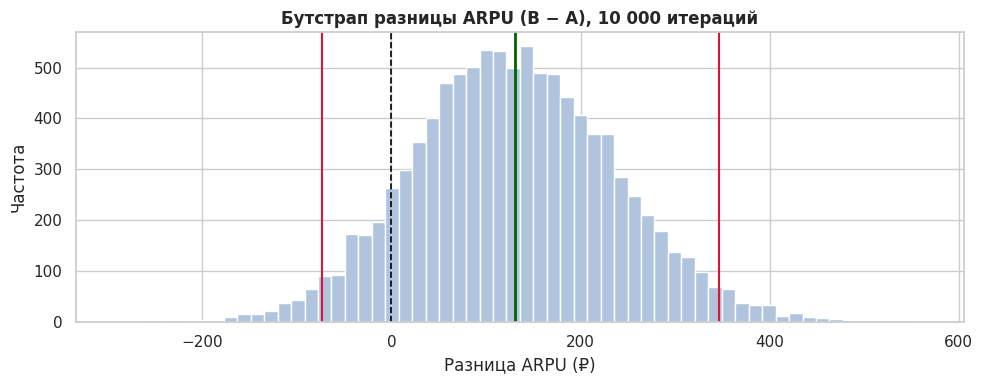

In [10]:
BOOTSTRAP_SAMPLES = 10_000
WINSOR_QUANTILE = 0.99


def bootstrap_mean_difference(control, treatment, samples=BOOTSTRAP_SAMPLES, seed=RANDOM_SEED):
    """Перцентильный бутстрап разницы средних между тестом и контролем."""
    generator = np.random.default_rng(seed)
    differences = np.empty(samples)

    for i in range(samples):
        differences[i] = (
            treatment[generator.integers(0, len(treatment), len(treatment))].mean()
            - control[generator.integers(0, len(control), len(control))].mean()
        )

    return differences


revenue_cap = np.quantile(ab_test.loc[ab_test['revenue'] > 0, 'revenue'], WINSOR_QUANTILE)
ab_test['revenue_winsorized'] = ab_test['revenue'].clip(upper=revenue_cap)

bootstrap_results = {}

for label, column in [('Выручка как есть', 'revenue'), ('Выручка с обрезкой хвоста', 'revenue_winsorized')]:
    control = ab_test.loc[ab_test['variant'] == 'A', column].to_numpy()
    treatment = ab_test.loc[ab_test['variant'] == 'B', column].to_numpy()

    differences = bootstrap_mean_difference(control, treatment)
    ci_low, ci_high = np.percentile(differences, [2.5, 97.5])
    observed = treatment.mean() - control.mean()

    bootstrap_results[label] = {
        'ARPU контроль': f'{control.mean():,.2f} ₽',
        'ARPU тест': f'{treatment.mean():,.2f} ₽',
        'Разница': f'{observed:+,.2f} ₽',
        'Относительный прирост': f'{observed / control.mean() * 100:+.2f}%',
        'Бутстрап 95% ДИ': f'[{ci_low:+,.2f}; {ci_high:+,.2f}] ₽',
        'Бутстрап p-value': f'{2 * min((differences <= 0).mean(), (differences >= 0).mean()):.4f}',
        't-тест Уэлча p-value': f'{stats.ttest_ind(treatment, control, equal_var=False).pvalue:.4f}',
        'Асимметрия': f'{pd.Series(np.concatenate([control, treatment])).skew():.2f}',
    }

    if column == 'revenue':
        raw_differences, raw_observed, raw_ci = differences, observed, (ci_low, ci_high)

print(f'Порог обрезки (99-й перцентиль среди платящих): {revenue_cap:,.0f} ₽')
display(pd.DataFrame(bootstrap_results))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(raw_differences, bins=60, color='lightsteelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.axvline(raw_ci[0], color='crimson', linewidth=1.5)
ax.axvline(raw_ci[1], color='crimson', linewidth=1.5)
ax.axvline(raw_observed, color='darkgreen', linewidth=2)
ax.set_title('Бутстрап разницы ARPU (B − A), 10 000 итераций', fontweight='bold')
ax.set_xlabel('Разница ARPU (₽)')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

### Влияние тяжёлого хвоста на чувствительность

Выручка без обработки: разница ARPU составляет +130.96 ₽ (+34.7%), однако бутстрап-интервал [−73.32; +346.88] включает ноль, p = 0.215. Вывод сделать невозможно: при асимметрии 77 разброс оценки перекрывает величину эффекта.

Выручка с винзоризацией по 99-му перцентилю платящих (порог 61 103 ₽): разница составляет +74.18 ₽ (+23.3%), интервал [+7.44; +141.01], p = 0.028, асимметрия снижается до 13.8. Эффект становится различимым.

Термин «винзоризация» означает замену экстремальных значений на пороговое: суммы выше 61 103 ₽ заменяются на этот порог, наблюдения при этом сохраняются.

t-тест Уэлча даёт сопоставимые выводы (p = 0.224 и p = 0.030), то есть расхождение обусловлено не выбором критерия, а обработкой метрики. Несколько B2B-сделок исчерпывают чувствительность теста.

**Оговорка о процедуре.** Порог обрезки в данном случае выбран после просмотра данных, что в реальном эксперименте недопустимо и представляет собой подгонку. Правило винзоризации фиксируется в дизайне до запуска. Приведённый расчёт носит иллюстративный характер и показывает степень зависимости результата от обработки хвоста.

## Сегментный анализ

In [11]:
def holm_adjust(p_values):
    """Поправка Холма на множественные сравнения."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0

    for rank, index in enumerate(order):
        candidate = (len(p_values) - rank) * p_values[index]
        running_max = max(running_max, candidate)
        adjusted[index] = min(running_max, 1.0)

    return adjusted


def segment_results(dimension, metric='primary_metric'):
    rows = []
    for value, group in ab_test.groupby(dimension):
        control = group.loc[group['variant'] == 'A', metric]
        treatment = group.loc[group['variant'] == 'B', metric]

        n_control, n_treatment = len(control), len(treatment)
        p_control, p_treatment = control.mean(), treatment.mean()

        pooled = (control.sum() + treatment.sum()) / (n_control + n_treatment)
        standard_error = np.sqrt(pooled * (1 - pooled) * (1 / n_control + 1 / n_treatment))
        z_stat = (p_treatment - p_control) / standard_error

        rows.append({
            'Сегмент': f'{dimension}: {value}',
            'N (A / B)': f'{n_control:,} / {n_treatment:,}',
            'CR A (%)': round(p_control * 100, 2),
            'CR B (%)': round(p_treatment * 100, 2),
            'Прирост (п.п.)': round((p_treatment - p_control) * 100, 2),
            'p-value': 2 * (1 - stats.norm.cdf(abs(z_stat))),
        })

    return pd.DataFrame(rows)


segments = pd.concat([segment_results('device_type'), segment_results('traffic_channel')],
                     ignore_index=True)
segments['p-value (Холм)'] = holm_adjust(segments['p-value'])
segments['Значимо без поправки'] = segments['p-value'] < ALPHA
segments['Значимо с поправкой'] = segments['p-value (Холм)'] < ALPHA
segments['p-value'] = segments['p-value'].round(4)
segments['p-value (Холм)'] = segments['p-value (Холм)'].round(4)

display(segments)

,Сегмент,N (A / B),CR A (%),CR B (%),Прирост (п.п.),p-value,p-value (Холм),Значимо без поправки,Значимо с поправкой
0,device_type: desktop,"4,783 / 4,775",4.50,5.13,0.64,0.1465,0.7982,False,False
1,device_type: mobile,"6,871 / 6,865",4.70,5.26,0.56,0.1330,0.7982,False,False
2,device_type: tablet,857 / 849,4.32,5.18,0.87,0.4008,1.0000,False,False
3,traffic_channel: influencers,"1,912 / 1,904",4.45,5.04,0.60,0.3861,1.0000,False,False
4,traffic_channel: organic,"4,354 / 4,350",4.85,4.90,0.05,0.9130,1.0000,False,False
5,traffic_channel: paid_search,"3,757 / 3,749",4.34,5.81,1.48,0.0036,0.0250,True,True
6,traffic_channel: targeted_ads,"2,488 / 2,486",4.66,4.95,0.29,0.6380,1.0000,False,False


### Статус сегментных результатов

Из семи сегментов эффект зафиксирован только для платного поиска: прирост 1.48 п.п., p = 0.0036. Результат сохраняет значимость и после поправки Холма (0.025). Поправка необходима по следующей причине: при выполнении семи сравнений подряд один значимый результат может быть получен случайно, и поправка учитывает это.

Тем не менее принимать решение по данному результату нельзя:

- размер выборки рассчитывался под общую метрику, а не под сегменты, вследствие чего мощности внутри отдельного среза недостаточно;
- отсутствует содержательное объяснение, по какой причине элемент интерфейса, ведущий в каталог, должен работать на платном поиске сильнее, чем на органическом трафике;
- в ноутбуке 03 на исторических данных различия между каналами не выявлены.

Сегментные результаты служат основанием для формулирования новых гипотез и последующей проверки отдельным экспериментом, но не для внедрения изменений.

## Выводы и рекомендации

## Выводы

**Результаты эксперимента.** Механика подтверждена: доходимость до каталога выросла на 7.17 п.п. при узком доверительном интервале. Конверсия в оплату выросла на 0.61 п.п. при p = 0.026, однако эффект находится ниже проектной чувствительности теста, а нижняя граница интервала близка к нулю.

**Рекомендации.**

1. **Не внедрять изменение по текущим данным.** Продлить набор наблюдений примерно до 30 тысяч на группу. Это обеспечит мощность для относительного прироста порядка 10% и позволит принять решение по первичной метрике, а не по пограничной значимости.
2. **Зафиксировать правило обработки крупных платежей в дизайне эксперимента.** Без винзоризации денежные метрики нечувствительны: несколько B2B-сделок перекрывают любой продуктовый эффект. Правило устанавливается до запуска теста, иначе результат подгоняется под ожидаемый.
3. **Выделить крупные сделки в отдельный анализ.** 0.1% пользователей, обеспечивающих четверть выручки, представляют собой самостоятельный B2B-сегмент с собственной воронкой и метриками.
4. **Параллельно готовить гипотезу H2.** Шаг 2 онбординга остаётся наиболее затратной точкой воронки и текущим экспериментом не затрагивается.
5. **Платный поиск рассматривать как предмет отдельного эксперимента,** а не как вывод настоящего.

**Ограничения.** Эксперимент измеряет краткосрочную конверсию в первую оплату. Влияние раннего входа в каталог на удержание и повторные покупки не определено; для его оценки требуется метрика на горизонте не менее месяца.